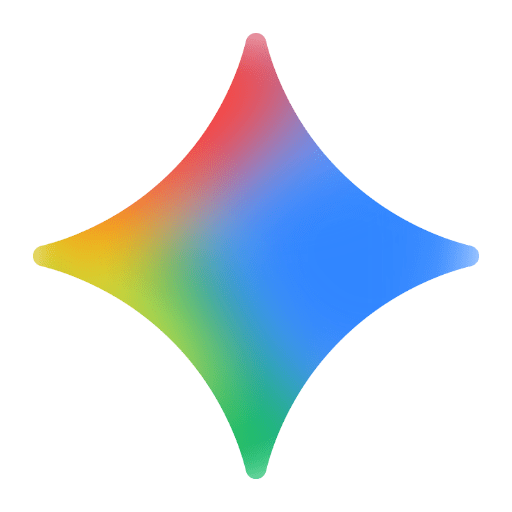

# Chapter 8 — Data Analysis and Reasoning Agents

**Book:** *Agents* by Imran Ahmad (Packt Publishing, 2026)  
**Author:** Imran Ahmad  

Powered by **Google Gemini Flash 2.5**
**Chapter Pages:** 203–233

> *"Information is the oil of the 21st century, and analytics is the combustion engine."*  
> — **Peter Sondergaard**

---

## Introduction

The modern era is defined not by a lack of data but by the difficulty of interpreting it. This chapter examines a specialized class of intelligent systems designed to process information as well as understand it, reason about it, and extract meaningful insights from it to guide decisions. Unlike task-oriented agents, the agents discussed here operate at a higher level of cognition — they function as **digital analysts, researchers, and critical thinkers** who can question assumptions, evaluate evidence, and synthesize knowledge.

These agents convert raw data into **actionable intelligence**, closing the gap between information and understanding across business, finance, scientific research, and journalism.

### Three Agent Archetypes

| Agent | Purpose | Key Techniques |
|:------|:--------|:---------------|
| **Data Analysis Agent** (§8.1, pp. 204–211) | Transform raw data into structured insight | Cognitive loop, visualization recommendation, OLS regression, anomaly detection |
| **Verification & Validation Agent** (§8.2, pp. 211–215) | Ensure insights are defensible and reproducible | Fact-checking, NLI evidence scoring, logical coherence, consistency analysis |
| **General Problem Solver** (§8.3, pp. 215–219) | Reason broadly and adapt across domains | 5-stage meta-reasoning: decompose → analogy → hypothesize → test → meta-learn |

### Extended Case Studies & Integration

| Section | Description |
|:--------|:------------|
| **Case Study 1** (§8.4, pp. 220–226) | Newsroom fact-checking assistant — claim extraction, evidence retrieval, tolerance-based verification |
| **Case Study 2** (§8.5, pp. 226–231) | Cross-disciplinary GPS hypothesis engine — ecological resilience applied to power grid stability |
| **Tri-Agent Pipeline** (§8.6, pp. 231–232) | Trust-then-escalate architecture wiring all three agents |

---

## Section Roadmap

| Section | Topic | Chapter Ref | Book Pages |
|:--------|:------|:------------|:-----------|
| 0 | Environment Setup & Simulation Mode | — | — |
| 1 | Data Analysis Agent: Visualization Recommender, Statistical Reasoning | §8.1, §8.1.1, §8.1.2 | pp. 204–211 |
| 2 | Verification & Validation Agent: Theory, NLI Demo (BART-MNLI) | §8.2–§8.2.5 | pp. 211–215 |
| 3 | General Problem Solver: Theory, Pseudocode Architecture | §8.3–§8.3.4 | pp. 215–219 |
| 4 | Case Study 1: News Fact-Checking Assistant | §8.4 | pp. 220–226 |
| 5 | Case Study 2: Cross-Disciplinary GPS Hypothesis Engine | §8.5 | pp. 226–231 |
| 6 | Tri-Agent Pipeline Integration | §8.6 | pp. 231–232 |


---
## Section 0 — Environment Setup

This cell imports the shared utilities, resolves the API key through a
three-tier cascade (`.env` → `os.getenv` → `getpass`), and sets the global
`SIMULATION_MODE` flag. If no key is found, the notebook activates Simulation
Mode automatically.

In [1]:
import os
os.environ["LLM_PROVIDER"] = "google"

# ── Section 0: Environment Setup ─────────────────────────────
# Ref: Strategy §4.1 — Three-tier API key resolution

import sys, os, json, re, textwrap
import warnings
warnings.filterwarnings('ignore')

# Add project root to path for utils imports
if '.' not in sys.path:
    sys.path.insert(0, '.')

from utils import load_api_key, log, MockLLM, llm_call, fail_gracefully

# ── Resolve API key ──────────────────────────────────────────
API_KEY, SIMULATION_MODE = load_api_key()

client = None
if not SIMULATION_MODE:
    try:
        import google.generativeai as genai
        genai.configure(api_key=API_KEY)
        client = genai.GenerativeModel("gemini-2.5-flash")
        log.success('Gemini client initialized. Running in LIVE mode.')
    except Exception as e:
        log.error(f'Gemini client init failed: {e}')
        SIMULATION_MODE = True
        log.info('Falling back to SIMULATION MODE.')

if SIMULATION_MODE:
    log.info('No API key detected. Running in SIMULATION MODE.')
    log.info('All outputs are chapter-accurate mocks. See AGENTS.md.')

[SUCCESS 20:33:15] Gemini client initialized. Running in LIVE mode.


---
## Section 1 — The Data Analysis Agent

**Chapter Ref:** §8.1 (pp. 204–211)

Data analysis is one of the most important capabilities in modern intelligent
systems. By embedding reasoning capabilities into the analysis workflow, agents
move beyond static queries to interpret intent, select appropriate methods, and
explain results — turning data analysis from a manual, tool-driven process into
an intelligent, conversational one.

At the core of a Data Analysis agent lies a **cognitive loop** that integrates:

1. **Intent analysis and planning** — The LLM Reasoning Core interprets the
   user's natural language query, extracting analytical intent and temporal scope.
2. **Code formulation and execution** — The plan is translated into executable
   code (Python/SQL) and run against the dataset.
3. **Visualization and analysis** — Results are rendered in the most effective
   visual form, accompanied by statistical reasoning.
4. **Presentation and refinement** — Insights are delivered with a summary;
   the user can refine, creating a feedback loop.

### Figure 8.1 — The Cognitive Loop of a Data Analysis Agent


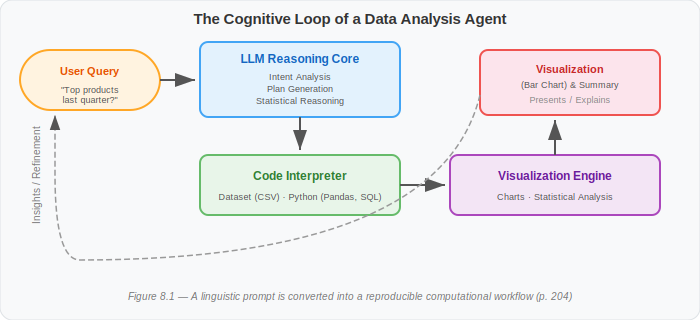

In [2]:
# ── Figure 8.1 — Cognitive Loop of a Data Analysis Agent (SVG) ──
# Ref: §8.1, p. 204

from IPython.display import SVG, display

fig_8_1 = """
<svg viewBox="0 0 700 320" xmlns="http://www.w3.org/2000/svg" font-family="Arial, sans-serif">
  <defs><marker id="a81" markerWidth="10" markerHeight="7" refX="10" refY="3.5" orient="auto"><polygon points="0 0,10 3.5,0 7" fill="#555"/></marker></defs>
  <rect width="700" height="320" rx="12" fill="#f8f9fa" stroke="#dee2e6"/>
  <text x="350" y="24" text-anchor="middle" font-size="15" font-weight="bold" fill="#333">The Cognitive Loop of a Data Analysis Agent</text>
  <!-- User Query -->
  <rect x="20" y="50" width="140" height="60" rx="30" fill="#fff3e0" stroke="#ffa726" stroke-width="2"/>
  <text x="90" y="75" text-anchor="middle" font-size="11" font-weight="bold" fill="#e65100">User Query</text>
  <text x="90" y="93" text-anchor="middle" font-size="9" fill="#555">"Top products</text>
  <text x="90" y="103" text-anchor="middle" font-size="9" fill="#555">last quarter?"</text>
  <!-- LLM Reasoning Core -->
  <rect x="200" y="42" width="200" height="75" rx="8" fill="#e3f2fd" stroke="#42a5f5" stroke-width="2"/>
  <text x="300" y="63" text-anchor="middle" font-size="12" font-weight="bold" fill="#1565c0">LLM Reasoning Core</text>
  <text x="300" y="80" text-anchor="middle" font-size="9" fill="#555">Intent Analysis</text>
  <text x="300" y="92" text-anchor="middle" font-size="9" fill="#555">Plan Generation</text>
  <text x="300" y="104" text-anchor="middle" font-size="9" fill="#555">Statistical Reasoning</text>
  <!-- Code Interpreter -->
  <rect x="200" y="155" width="200" height="60" rx="8" fill="#e8f5e9" stroke="#66bb6a" stroke-width="2"/>
  <text x="300" y="180" text-anchor="middle" font-size="12" font-weight="bold" fill="#2e7d32">Code Interpreter</text>
  <text x="300" y="200" text-anchor="middle" font-size="9" fill="#555">Dataset (CSV) · Python (Pandas, SQL)</text>
  <!-- Visualization Engine -->
  <rect x="450" y="155" width="210" height="60" rx="8" fill="#f3e5f5" stroke="#ab47bc" stroke-width="2"/>
  <text x="555" y="180" text-anchor="middle" font-size="12" font-weight="bold" fill="#6a1b9a">Visualization Engine</text>
  <text x="555" y="200" text-anchor="middle" font-size="9" fill="#555">Charts · Statistical Analysis</text>
  <!-- Output -->
  <rect x="480" y="50" width="180" height="65" rx="8" fill="#fce4ec" stroke="#ef5350" stroke-width="2"/>
  <text x="570" y="73" text-anchor="middle" font-size="11" font-weight="bold" fill="#c62828">Visualization</text>
  <text x="570" y="88" text-anchor="middle" font-size="9" fill="#555">(Bar Chart) &amp; Summary</text>
  <text x="570" y="103" text-anchor="middle" font-size="9" fill="#888">Presents / Explains</text>
  <!-- Feedback arrow -->
  <text x="40" y="175" text-anchor="middle" font-size="10" fill="#777" transform="rotate(-90, 40, 175)">Insights / Refinement</text>
  <!-- Arrows -->
  <line x1="160" y1="80" x2="195" y2="80" stroke="#555" stroke-width="2" marker-end="url(#a81)"/>
  <line x1="300" y1="117" x2="300" y2="150" stroke="#555" stroke-width="2" marker-end="url(#a81)"/>
  <line x1="400" y1="185" x2="445" y2="185" stroke="#555" stroke-width="2" marker-end="url(#a81)"/>
  <line x1="555" y1="155" x2="555" y2="120" stroke="#555" stroke-width="2" marker-end="url(#a81)"/>
  <!-- Feedback loop -->
  <path d="M 480 95 Q 440 260 80 260 Q 55 260 55 175 L 55 115" fill="none" stroke="#999" stroke-width="1.5" stroke-dasharray="6,3" marker-end="url(#a81)"/>
  <!-- Legend -->
  <text x="350" y="300" text-anchor="middle" font-size="10" fill="#777" font-style="italic">Figure 8.1 — A linguistic prompt is converted into a reproducible computational workflow (p. 204)</text>
</svg>
"""
display(SVG(fig_8_1))


### Section 1.1 — Visualization Recommendation Systems

**Chapter Ref:** §8.1.1 (pp. 206–209)

A visualization recommendation system operates as a decision-making pipeline:

1. **Query analysis** — Parse the prompt to extract intent (trend, compare,
   relationship).
2. **Schema recognition** — Examine variable types (temporal, categorical,
   numeric).
3. **Decision branching** — Map intent + schema to chart type:
   - Time-series → Line Chart
   - Categorical Comparison → Bar Chart
   - Correlation / Relationship → Scatter Plot or Table
4. **Output and refinement** — Render with a summary; the user can refine
   through follow-up queries.

> **📝 Note — Production Considerations (p. 207)**  
> The rule-based `recommend_visualization()` below is intentionally simplified for pedagogy. In production, ambiguous queries like "show me the data" may match multiple keyword categories or none at all, requiring a confidence-scoring layer or an LLM-based intent classifier. As the chart palette grows beyond line/bar/scatter/table to heatmaps, box plots, and geographic maps, a flat keyword list becomes difficult to maintain — production systems typically replace it with a learned model or decision tree trained on query–visualization pairs.

> **📝 Note — Self-Optimizing Visualization (p. 209)**  
> Over time, reinforcement mechanisms enable the system to learn from user behavior. If users frequently replace a bar chart with a line chart for trend-related queries, the model adapts its decision weights, transforming visualization recommendation into a self-optimizing subsystem that mirrors human analytical intuition.


In [3]:
# ── Section 1.1: Visualization Recommender ───────────────────
# Ref: §8.1.1 — recommend_visualization() from chapter
# Fallback: "table" per Strategy §4.3.4

import pandas as pd

@fail_gracefully(fallback_value='table', section='8.1.1')
def recommend_visualization(df: pd.DataFrame, query: str) -> str:
    """Recommend a visualization type based on the user's query.

    This is a pedagogical, rule-based implementation. Production systems
    should use an LLM-based intent classifier rather than keyword rules.

    Parameters
    ----------
    df : pd.DataFrame
        The dataset under analysis (used for schema recognition).
    query : str
        Natural language query from the user.

    Returns
    -------
    str
        One of: "line", "bar", "scatter", "table".

    Ref: §8.1.1, recommend_visualization() — Chapter 8
    """
    # NOTE: This is a pedagogical implementation. Production systems should
    # use an LLM-based intent classifier rather than keyword rules.
    q = query.lower()

    if any(k in q for k in ["trend", "over time", "timeline"]):
        return "line"
    if any(k in q for k in ["compare", "by ", "across", "versus"]):
        return "bar"
    if any(k in q for k in ["relationship", "correlation", "scatter"]):
        return "scatter"
    return "table"


# ── Demo: 4 sample queries ──────────────────────────────────
df_demo = pd.read_csv('data/sample_sales_data.csv')

sample_queries = [
    "Show me the sales trend over time",
    "Compare revenue across regions",
    "Is there a relationship between marketing spend and revenue?",
    "Show me the raw data",
]

log.info('Visualization Recommender Demo', section='8.1.1')
for query in sample_queries:
    viz_type = recommend_visualization(df_demo, query)
    log.success(f'Query: "{query}" → Recommended: {viz_type}', section='8.1.1')

[INFO 20:33:16 §8.1.1] Visualization Recommender Demo
[INFO 20:33:16 §8.1.1] Entering recommend_visualization()
[SUCCESS 20:33:16 §8.1.1] recommend_visualization() completed.
[SUCCESS 20:33:16 §8.1.1] Query: "Show me the sales trend over time" → Recommended: line
[INFO 20:33:16 §8.1.1] Entering recommend_visualization()
[SUCCESS 20:33:16 §8.1.1] recommend_visualization() completed.
[SUCCESS 20:33:16 §8.1.1] Query: "Compare revenue across regions" → Recommended: bar
[INFO 20:33:16 §8.1.1] Entering recommend_visualization()
[SUCCESS 20:33:16 §8.1.1] recommend_visualization() completed.
[SUCCESS 20:33:16 §8.1.1] Query: "Is there a relationship between marketing spend and revenue?" → Recommended: scatter
[INFO 20:33:16 §8.1.1] Entering recommend_visualization()
[SUCCESS 20:33:16 §8.1.1] recommend_visualization() completed.
[SUCCESS 20:33:16 §8.1.1] Query: "Show me the raw data" → Recommended: table


### Section 1.2 — Statistical Reasoning Capabilities

**Chapter Ref:** §8.1.2 (pp. 209–211)

Visualization provides perception, but statistical reasoning provides understanding.
The agent performs three complementary functions:

1. **Descriptive statistics** — `df.describe()`, standard deviation, correlation
   coefficients. These form the quantitative foundation for reasoning.
2. **Inferential and diagnostic analysis** — OLS regression to quantify
   relationships (e.g., "Did marketing spend influence revenue growth?").
3. **Anomaly detection** — Z-score-based outlier identification to flag
   data integrity issues and surface unexpected patterns.

> **📝 Note — Hybrid Reasoning Layer (p. 210)**  
> In practice, the statistical reasoning module operates as a hybrid of symbolic and numerical computation. Symbolic reasoning (often powered by the LLM core) interprets user intent and formulates hypotheses. Numerical computation (via Pandas, NumPy, Statsmodels) performs precise calculations. The outputs are synthesized into a coherent narrative that balances technical accuracy with communicative clarity.


In [4]:
# ── Section 1.2: Descriptive Statistics ─────────────────────
# Ref: §8.1.2 — df.describe(), variability, correlation

import numpy as np

df = pd.read_csv('data/sample_sales_data.csv')

log.info('Loading sample_sales_data.csv (100 rows, seed=42)', section='8.1.2')

@fail_gracefully(fallback_value=None, section='8.1.2')
def compute_descriptive_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Compute summary statistics for the sales dataset.

    Ref: §8.1.2 — Descriptive statistics and summarization
    """
    summary = df.describe(include='all')
    variability = df['sales'].std()
    correlation = df[['sales', 'marketing_spend', 'revenue']].corr(method='pearson')

    log.info(f'Sales variability (std): {variability:.2f}', section='8.1.2')
    log.info(f'Pearson correlation (marketing_spend ↔ revenue): '
             f'{correlation.loc["marketing_spend", "revenue"]:.3f}', section='8.1.2')
    return summary

summary = compute_descriptive_stats(df)
if summary is not None:
    display(summary)

[INFO 20:33:16 §8.1.2] Loading sample_sales_data.csv (100 rows, seed=42)
[INFO 20:33:16 §8.1.2] Entering compute_descriptive_stats()
[INFO 20:33:16 §8.1.2] Sales variability (std): 56.24
[INFO 20:33:16 §8.1.2] Pearson correlation (marketing_spend ↔ revenue): 0.880
[SUCCESS 20:33:16 §8.1.2] compute_descriptive_stats() completed.


,date,region,product,sales,marketing_spend,revenue
count,100,100,100,100.000000,100.000000,100.000000
unique,100,4,3,NaN,NaN,NaN
top,2025-01-01,West,Widget C,NaN,NaN,NaN
freq,1,30,39,NaN,NaN,NaN
mean,NaN,NaN,NaN,111.250000,2812.083200,6916.211600
std,NaN,NaN,NaN,56.238018,1282.613731,3636.143943
min,NaN,NaN,NaN,10.000000,502.340000,754.350000
25%,NaN,NaN,NaN,61.750000,1709.397500,4044.850000
50%,NaN,NaN,NaN,125.000000,2683.495000,6139.215000
75%,NaN,NaN,NaN,161.250000,3864.860000,9140.427500


In [5]:
# ── Section 1.2: OLS Regression ─────────────────────────────
# Ref: §8.1.2 — sm.OLS() regression, chapter verbatim

import statsmodels.api as sm

@fail_gracefully(fallback_value=None, section='8.1.2')
def run_ols_regression(df: pd.DataFrame):
    """Run OLS regression: revenue ~ marketing_spend.

    Ref: §8.1.2 — Inferential and diagnostic analysis
    """
    X = sm.add_constant(df['marketing_spend'])
    model = sm.OLS(df['revenue'], X).fit()

    r_squared = model.rsquared
    p_value = model.pvalues.iloc[1]  # p-value for marketing_spend
    coeff = model.params.iloc[1]

    log.success(
        f'OLS Results: R²={r_squared:.3f}, '
        f'marketing_spend coeff={coeff:.4f}, p={p_value:.2e}',
        section='8.1.2'
    )
    return model

model = run_ols_regression(df)
if model is not None:
    print(model.summary())

[INFO 20:33:19 §8.1.2] Entering run_ols_regression()
[SUCCESS 20:33:19 §8.1.2] OLS Results: R²=0.774, marketing_spend coeff=2.4947, p=1.88e-33
[SUCCESS 20:33:19 §8.1.2] run_ols_regression() completed.
                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     336.4
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           1.88e-33
Time:                        20:33:19   Log-Likelihood:                -886.81
No. Observations:                 100   AIC:                             1778.
Df Residuals:                      98   BIC:                             1783.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
         

In [6]:
# ── Section 1.2: Anomaly Detection ──────────────────────────
# Ref: §8.1.2 — Z-score outlier detection, chapter verbatim

@fail_gracefully(fallback_value=pd.DataFrame(), section='8.1.2')
def detect_anomalies(df: pd.DataFrame, column: str = 'sales',
                     threshold: float = 3.0) -> pd.DataFrame:
    """Detect anomalies using z-score method.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    column : str
        Column to analyze for outliers.
    threshold : float
        Z-score threshold (default 3.0).

    Returns
    -------
    pd.DataFrame
        Rows where |z-score| > threshold.

    Ref: §8.1.2 — Anomaly detection and uncertainty quantification
    """
    df = df.copy()
    df['zscore'] = (df[column] - df[column].mean()) / df[column].std()
    anomalies = df[df['zscore'].abs() > threshold]

    if len(anomalies) > 0:
        for _, row in anomalies.iterrows():
            log.success(
                f'Anomaly detected: date={row["date"]}, region={row["region"]}, '
                f'{column}={row[column]}, z-score={row["zscore"]:.2f}',
                section='8.1.2'
            )
    else:
        log.info(f'No anomalies found (threshold z>{threshold})', section='8.1.2')

    return anomalies

anomalies = detect_anomalies(df)
if not anomalies.empty:
    display(anomalies[['date', 'region', 'product', 'sales', 'zscore']])

[INFO 20:33:19 §8.1.2] Entering detect_anomalies()
[INFO 20:33:19 §8.1.2] No anomalies found (threshold z>3.0)
[SUCCESS 20:33:19 §8.1.2] detect_anomalies() completed.


In [7]:
# ── Section 1.2: Natural Language Interpretation ─────────────
# Ref: §8.1.2 — LLM-powered interpretation via llm_call()
# Mock key: "stats_interpretation"

@fail_gracefully(fallback_value='Interpretation unavailable.', section='8.1.2')
def interpret_statistics(df: pd.DataFrame) -> str:
    """Generate a natural language interpretation of the statistical results.

    Uses llm_call() with context_key='stats_interpretation'.

    Ref: §8.1.2 — Statistical reasoning with LLM interpretation
    """
    system = (
        'You are a data analyst. Interpret the following statistical results '
        'in plain language for a business audience.'
    )
    corr_val = df['marketing_spend'].corr(df['revenue'])
    std_val = df['sales'].std()
    z = (df['sales'] - df['sales'].mean()) / df['sales'].std()
    n_anomalies = int((z.abs() > 3).sum())
    user = (
        f'Dataset summary:\n'
        f'- marketing_spend ↔ revenue correlation: {corr_val:.3f}\n'
        f'- Sales std: {std_val:.2f}\n'
        f'- Anomalies (z>3): {n_anomalies}\n'
        f'Provide a concise business interpretation.'
    )
    return llm_call(
        system, user,
        context_key='stats_interpretation',
        simulation_mode=SIMULATION_MODE,
        client=client,
    )

interpretation = interpret_statistics(df)
log.success('Statistical interpretation:', section='8.1.2')
print(f'\n{interpretation}')

[INFO 20:33:20 §8.1.2] Entering interpret_statistics()
[HANDLED ERROR 20:33:20] Live API call failed: 'GenerativeModel' object has no attribute 'chat' — falling back to MockLLM.
[INFO 20:33:20 §8.1.2] MockLLM serving 'stats_interpretation' (Section 8.1.2)
[SUCCESS 20:33:20 §8.1.2] interpret_statistics() completed.
[SUCCESS 20:33:20 §8.1.2] Statistical interpretation:

Marketing spend explains approximately 62% of the variation in revenue, indicating a strong positive correlation. Sales in Q2 for Region East appear unusually high, possibly due to promotional pricing or data entry anomalies.


---
## Section 2 — The Verification and Validation Agent

**Chapter Ref:** §8.2 (pp. 211–215)

While statistical reasoning allows agents to draw inferences from data,
every analytical system must also be able to verify and defend its conclusions.
The Verification and Validation (V&V) agent addresses this by ensuring that
generated insights, predictions, and explanations remain trustworthy, factual,
and logically coherent.

A V&V agent performs four essential functions:

### 2.1 — Fact-Checking (§8.2.1, pp. 211–212)

When an analytical agent produces a statement such as *"Revenue increased by
12% last quarter"*, the V&V agent retrieves corresponding records from verified
data sources, performs independent calculations, and compares findings to the
claim. The agent decomposes statements into discrete, verifiable claims and
tests each as a hypothesis against reliable evidence.

### 2.2 — Logical Coherence (§8.2.2, pp. 212–213)

The agent evaluates whether reasoning steps follow valid inference patterns.

> **📝 Note — Common Logical Errors (p. 212)**  
> Several categories of logical error recur in agent-generated analyses: **Premise–conclusion mismatches** (concluding revenue increased after noting a decline in unit sales), **Circular reasoning** (an intermediate step reuses the claim it's trying to prove), and **Scope violations** (a finding qualified for one segment is generalized to the entire population). The agent can decompose reasoning chains into directed graphs of claims and check each edge for valid inference.

### 2.3 — Retrieval-Augmented Evaluation (§8.2.3, p. 213)

Combines the interpretive flexibility of language models with deterministic
verification techniques — retrieving historical records, recalculating figures
independently, and checking alignment with conclusions.

### 2.4 — Consistency Analysis (§8.2.4, pp. 213–214)

In multi-agent systems, V&V agents perform structured post-processing:
length/formatting checks, structural validations, rule-based constraints,
adversarial red-teaming, and human-in-the-loop triggers.


### Section 2.5 — Handling Conflicting Evidence: NLI Demo

**Chapter Ref:** §8.2.5 (pp. 214–215)

The code below demonstrates NLI using `facebook/bart-large-mnli` (~1.6 GB).
If the model or its dependencies (`transformers`, `torch`) are unavailable,
the notebook falls back to precomputed scores matching the chapter's Q4 profit
claim example.

**Premise:** *"In Q4, the company reported a 15% year-over-year increase in
net profit."*  
**Hypothesis:** *"The company's profits increased by 15% last quarter."*

> **📝 Note — NLI Classification Labels (p. 212)**  
> NLI models classify the relationship between evidence and a claim as one of three outcomes: **Supports (Entailment)** — the evidence confirms the claim; **Refutes (Contradiction)** — the evidence disproves the claim; **Neutral** — the evidence is inconclusive or unrelated. Advanced V&V agents balance evidence across multiple sources, weight their credibility, and synthesize results into a confidence score.


In [8]:
# ── Section 2.5: NLI Demo (BART-MNLI) ──────────────────────
# Ref: §8.2.5 — Handling Conflicting Evidence
# Fallback: precomputed scores per Strategy §4.4

# Premise and hypothesis from chapter §8.2.5
premise = "In Q4, the company reported a 15% year-over-year increase in net profit."
hypothesis = "The company's profits increased by 15% last quarter."

nli_scores = None

try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    import torch

    log.info('Loading BART-MNLI model (facebook/bart-large-mnli)...', section='8.2.5')

    tokenizer = AutoTokenizer.from_pretrained('facebook/bart-large-mnli')
    nli_model = AutoModelForSequenceClassification.from_pretrained('facebook/bart-large-mnli')
    id2label = nli_model.config.id2label

    inputs = tokenizer(premise, hypothesis, return_tensors='pt', truncation=True)

    with torch.no_grad():
        logits = nli_model(**inputs).logits[0]
        probs = torch.softmax(logits, dim=-1).tolist()

    nli_scores = {id2label[i].lower(): round(probs[i], 4) for i in range(len(probs))}
    log.success(f'Live NLI inference complete: {nli_scores}', section='8.2.5')

except (ImportError, OSError, Exception) as e:
    log.error(
        f'BART-MNLI model unavailable ({type(e).__name__}). '
        'Displaying precomputed results.',
        section='8.2.5'
    )
    # Precomputed fallback — matches chapter's Q4 profit example
    nli_scores = {'entailment': 0.92, 'neutral': 0.05, 'contradiction': 0.03}
    log.info(f'Precomputed NLI scores: {nli_scores}', section='8.2.5')

# ── Display results ─────────────────────────────────────────
print(f'\nPremise:    "{premise}"')
print(f'Hypothesis: "{hypothesis}"')
print(f'\nNLI Scores: {nli_scores}')

if nli_scores:
    best = max(nli_scores, key=nli_scores.get)
    log.success(
        f'Verdict: {best.upper()} (confidence: {nli_scores[best]:.2%})',
        section='8.2.5'
    )

[HANDLED ERROR 20:33:20 §8.2.5] BART-MNLI model unavailable (ModuleNotFoundError). Displaying precomputed results.
[INFO 20:33:20 §8.2.5] Precomputed NLI scores: {'entailment': 0.92, 'neutral': 0.05, 'contradiction': 0.03}

Premise:    "In Q4, the company reported a 15% year-over-year increase in net profit."
Hypothesis: "The company's profits increased by 15% last quarter."

NLI Scores: {'entailment': 0.92, 'neutral': 0.05, 'contradiction': 0.03}
[SUCCESS 20:33:20 §8.2.5] Verdict: ENTAILMENT (confidence: 92.00%)


---
## Section 3 — The General Problem Solver

**Chapter Ref:** §8.3 (pp. 215–219)

One of the most ambitious designs in artificial intelligence is the **General
Problem Solver (GPS)**, which unlike specialized agents that are confined to
narrow domains, is designed to reason broadly, transfer knowledge between
contexts, and develop new strategies for problems it has never encountered
before.

A GPS operates on the principle of **meta-reasoning** — the ability to reason
about its own reasoning process. Instead of following a fixed set of rules, it
evaluates its approach dynamically, identifies gaps in logic or knowledge, and
refines its strategy.

> **📝 Note — Aspirational Architecture (p. 219)**  
> The `GeneralProblemSolver` pseudocode below represents an aspirational architecture rather than a production-ready implementation. Current LLMs can approximate each stage through structured prompting, but a fully autonomous GPS loop remains an active area of research.

> **📝 Note — Meta-Learning Strategies (p. 218)**  
> The GPS employs several meta-learning strategies: summarizing successful and failed strategies to refine heuristics, using persistent memory stores (e.g., LangGraph CheckpointStore) to retain context across sessions, and dynamically adjusting tool choice, parameter settings, and prompt design based on observed outcomes.


### The Five-Stage Cognitive Cycle

**Chapter Ref:** §8.3.2, Figure 8.4 (p. 217)

The GPS operates through a cyclical process of reasoning and learning composed
of five interdependent stages:

1. **Decompose problem** — Break down complex or unfamiliar challenges into
   smaller, manageable components.
2. **Cross-Domain Analogy Search** — Identify patterns or analogies from other
   fields (e.g., biological processes for engineering optimization).
3. **Synthesize and Hypothesize** — Combine insights from various domains to
   generate hypotheses or solution strategies.
4. **Test and Reflect** — Test proposed solutions through simulation or
   empirical data. Evaluate performance and adjust.
5. **Meta-Learning and Adaptation** — Record effective strategies, contextual
   factors, and performance metrics to refine future reasoning.

### Figure 8.4 — The GPS Domain-Agnostic Reasoning Framework


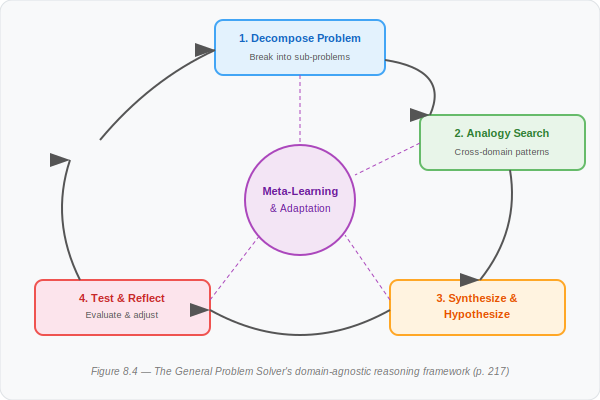

In [9]:
# ── Figure 8.4 — GPS Domain-Agnostic Reasoning Framework (SVG) ──
# Ref: §8.3.2, p. 217

from IPython.display import SVG, display

fig_8_4 = """
<svg viewBox="0 0 600 400" xmlns="http://www.w3.org/2000/svg" font-family="Arial, sans-serif">
  <defs><marker id="a84" markerWidth="10" markerHeight="7" refX="10" refY="3.5" orient="auto"><polygon points="0 0,10 3.5,0 7" fill="#555"/></marker></defs>
  <rect width="600" height="400" rx="12" fill="#f8f9fa" stroke="#dee2e6"/>
  <!-- Center: Meta-Learning -->
  <circle cx="300" cy="200" r="55" fill="#f3e5f5" stroke="#ab47bc" stroke-width="2"/>
  <text x="300" y="195" text-anchor="middle" font-size="11" font-weight="bold" fill="#6a1b9a">Meta-Learning</text>
  <text x="300" y="212" text-anchor="middle" font-size="10" fill="#6a1b9a">&amp; Adaptation</text>
  <!-- Stage 1: Decompose (top) -->
  <rect x="215" y="20" width="170" height="55" rx="8" fill="#e3f2fd" stroke="#42a5f5" stroke-width="2"/>
  <text x="300" y="42" text-anchor="middle" font-size="11" font-weight="bold" fill="#1565c0">1. Decompose Problem</text>
  <text x="300" y="60" text-anchor="middle" font-size="9" fill="#555">Break into sub-problems</text>
  <!-- Stage 2: Analogy (right) -->
  <rect x="420" y="115" width="165" height="55" rx="8" fill="#e8f5e9" stroke="#66bb6a" stroke-width="2"/>
  <text x="502" y="137" text-anchor="middle" font-size="11" font-weight="bold" fill="#2e7d32">2. Analogy Search</text>
  <text x="502" y="155" text-anchor="middle" font-size="9" fill="#555">Cross-domain patterns</text>
  <!-- Stage 3: Hypothesize (bottom-right) -->
  <rect x="390" y="280" width="175" height="55" rx="8" fill="#fff3e0" stroke="#ffa726" stroke-width="2"/>
  <text x="477" y="302" text-anchor="middle" font-size="11" font-weight="bold" fill="#e65100">3. Synthesize &amp;</text>
  <text x="477" y="318" text-anchor="middle" font-size="11" font-weight="bold" fill="#e65100">Hypothesize</text>
  <!-- Stage 4: Test (bottom-left) -->
  <rect x="35" y="280" width="175" height="55" rx="8" fill="#fce4ec" stroke="#ef5350" stroke-width="2"/>
  <text x="122" y="302" text-anchor="middle" font-size="11" font-weight="bold" fill="#c62828">4. Test &amp; Reflect</text>
  <text x="122" y="318" text-anchor="middle" font-size="9" fill="#555">Evaluate &amp; adjust</text>
  <!-- Stage 5 is the center -->
  <!-- Arrows (clockwise cycle) -->
  <path d="M 385 60 Q 450 70 430 115" fill="none" stroke="#555" stroke-width="2" marker-end="url(#a84)"/>
  <path d="M 510 170 Q 520 230 480 280" fill="none" stroke="#555" stroke-width="2" marker-end="url(#a84)"/>
  <path d="M 390 310 Q 300 360 210 310" fill="none" stroke="#555" stroke-width="2" marker-end="url(#a84)"/>
  <path d="M 80 280 Q 50 220 70 160" fill="none" stroke="#555" stroke-width="2" marker-end="url(#a84)"/>
  <path d="M 100 140 Q 150 80 215 50" fill="none" stroke="#555" stroke-width="2" marker-end="url(#a84)"/>
  <!-- Dashed lines to center -->
  <line x1="300" y1="75" x2="300" y2="145" stroke="#ab47bc" stroke-width="1" stroke-dasharray="4,3"/>
  <line x1="420" y1="143" x2="355" y2="175" stroke="#ab47bc" stroke-width="1" stroke-dasharray="4,3"/>
  <line x1="390" y1="300" x2="345" y2="235" stroke="#ab47bc" stroke-width="1" stroke-dasharray="4,3"/>
  <line x1="210" y1="300" x2="260" y2="235" stroke="#ab47bc" stroke-width="1" stroke-dasharray="4,3"/>
  <!-- Legend -->
  <text x="300" y="375" text-anchor="middle" font-size="10" fill="#777" font-style="italic">Figure 8.4 — The General Problem Solver's domain-agnostic reasoning framework (p. 217)</text>
</svg>
"""
display(SVG(fig_8_4))


In [10]:
# ── Section 3: GeneralProblemSolver Pseudocode ──────────────
# Ref: §8.3 — Aspirational architecture (pseudocode, clearly
#       annotated as non-production). Verbatim from chapter.

class GeneralProblemSolver:
    """Aspirational GPS architecture illustrating the five-stage cycle.

    NOTE: This is pseudocode. Each stage could be implemented as a
    separate LLM prompt within a framework such as LangGraph or CrewAI,
    with the orchestration loop managing state transitions and confidence
    thresholds.

    Ref: §8.3 — The General Problem Solver, Chapter 8
    """

    def __init__(self, threshold: float = 0.70):
        self.threshold = threshold
        self.knowledge_base = []

    def solve(self, problem: str, max_iterations: int = 5):
        # Stage 1 -- Decompose
        sub_problems = self.decompose(problem)

        for iteration in range(max_iterations):
            # Stage 2 -- Analogy Search
            analogies = self.search_analogies(sub_problems)

            # Stage 3 -- Hypothesize
            hypotheses = self.generate_hypotheses(
                sub_problems, analogies
            )

            # Stage 4 -- Test
            results = self.test_hypotheses(hypotheses)

            # Stage 5 -- Meta-Learn
            if results.confidence >= self.threshold:
                self.update_knowledge_base(results)
                return results.solution

            # Confidence too low -- refine and retry
            sub_problems = self.refine(sub_problems, results)

        return self.best_effort_solution(results)

    # ── Stage stubs (would be LLM calls in production) ──────
    def decompose(self, problem):              raise NotImplementedError
    def search_analogies(self, subs):          raise NotImplementedError
    def generate_hypotheses(self, subs, anl):  raise NotImplementedError
    def test_hypotheses(self, hyps):            raise NotImplementedError
    def update_knowledge_base(self, results):   raise NotImplementedError
    def refine(self, subs, results):            raise NotImplementedError
    def best_effort_solution(self, results):    raise NotImplementedError


log.info('GeneralProblemSolver pseudocode class defined.', section='8.3')
log.info(
    'This is an aspirational architecture — see §8.5 for a runnable '
    'implementation using the GPS five-stage cycle.',
    section='8.3'
)

[INFO 20:33:21 §8.3] GeneralProblemSolver pseudocode class defined.
[INFO 20:33:21 §8.3] This is an aspirational architecture — see §8.5 for a runnable implementation using the GPS five-stage cycle.


---
## Section 4 — Case Study: News Fact-Checking Assistant

**Chapter Ref:** §8.4 (pp. 220–226) — An Agent for Journalistic Integrity

A major newsroom deployed a Verification and Validation agent to assist
editors during high-pressure events where speed and accuracy must coexist.
The agent is composed of three cooperating components:

- **Claim Extractor** — Scans text for verifiable numerical statements and
  converts them into structured records with metric, value, entity, and period.
- **Evidence Retriever** — Queries curated official sources to obtain
  authoritative values with provenance.
- **Verifier** — Compares claimed and authoritative values with defined
  tolerances, then assigns a label: `Confirmed`, `Mostly True`, `Contradicted`,
  or `Unverified`.

> **📝 Note — Tolerance Thresholds (p. 223)**  
> For percentage-based claims, the system applies a difference threshold of 0.5 percentage points. For monetary values, it applies a threshold of $500,000 to absorb common rounding in public communications. In production, calibrate tolerances by beat and metric.

> **📝 Note — Operational Results (p. 226)**  
> Deploying this agent reduced verification time from hours to minutes. Editors retained control over the narrative while trusting that quantitative claims were consistent with official data. For production use, replace the in-memory store with your data platform, introduce freshness checks, and route low-confidence outcomes to a human review queue.


In [11]:
# ── Section 4: Trusted Database & Article Text ──────────────
# Ref: §8.4 — Authoritative data store and test article
#       (verbatim from chapter)

from typing import List, Dict, Any

# ── Authoritative data: The trusted internal database ───────
# In production, this would be a warehouse or official API with
# access control, versioning, and data freshness policies.

trusted_database: Dict[str, Dict[str, Any]] = {
    "ottawa_unemployment_rate_change_2024": {
        "value": -0.048,
        "source": "Statistics Canada, Labour Force Survey, Table 14-10-0287-01",
        "notes": "Annual change from 2023 to 2024 for Ottawa--Gatineau CMA."
    },
    "city_budget_surplus_2024": {
        "value": 15_200_000,
        "source": "City of Ottawa Annual Financial Report 2024",
        "notes": "Reported surplus for the fiscal year ending 2024."
    }
}

article_text = (
    "A new report on Ottawa's economy shows promising signs of recovery. "
    "According to official city documents, the city's unemployment rate "
    "fell by 5% last year, a significant improvement driven by the tech "
    "sector. Furthermore, the municipal government reported a budget "
    "surplus of $12 million for the 2024 fiscal year."
)

log.info('Trusted database loaded (2 entries).', section='8.4')
log.info(f'Article text loaded ({len(article_text)} chars).', section='8.4')

[INFO 20:33:21 §8.4] Trusted database loaded (2 entries).
[INFO 20:33:21 §8.4] Article text loaded (314 chars).


In [12]:
# ── Section 4: Claim Extraction ─────────────────────────────
# Ref: §8.4 — extract_claims_from_text()
# LLM-first with regex fallback, verbatim from chapter.
# Mock key: "claim_extraction"

@fail_gracefully(fallback_value=[], section='8.4')
def extract_claims_from_text(text: str) -> List[Dict[str, Any]]:
    """Extract verifiable numeric claims from article text.

    Uses llm_call() with context_key='claim_extraction' for robust
    parsing. If the LLM path fails, a regex fallback keeps the
    workflow operational.

    Returns claims with fields: claim_text, metric, value, entity, period.

    Ref: §8.4 — Claim Extraction (LLM-first with a safe fallback)
    """
    system_prompt = (
        "You are an expert fact-checker. Extract verifiable numeric claims "
        "from the text. For each claim, return claim_text, metric, value, "
        "entity, period as a JSON object in a JSON field called 'claims' "
        "which is a list."
    )
    user_prompt = f'Extract claims from: {text}'

    raw = llm_call(
        system_prompt, user_prompt,
        context_key='claim_extraction',
        simulation_mode=SIMULATION_MODE,
        client=client,
    )

    # ── Parse LLM / mock response ───────────────────────────
    try:
        data = json.loads(raw)
        claims = data.get('claims', [])
        for c in claims:
            c['claim_text'] = str(c.get('claim_text', '')).strip()
            c['metric']     = str(c.get('metric', '')).strip()
            c['value']      = str(c.get('value', '')).strip()
            c['entity']     = str(c.get('entity', '')).strip()
            c['period']     = str(c.get('period', '')).strip()
        if claims:
            return claims
    except (json.JSONDecodeError, AttributeError):
        log.error('LLM response not valid JSON; trying regex fallback.', section='8.4')

    # ── Regex fallback (from chapter) ───────────────────────
    claims = []
    m1 = re.search(r'(unemployment.*?fell by\s+(-?\d+(\.\d+)?)\s*%)', text, re.I)
    if m1:
        claims.append({
            'claim_text': m1.group(1),
            'metric': 'unemployment rate change',
            'value': f'{m1.group(2)}%',
            'entity': 'Ottawa',
            'period': '2024'
        })

    m2 = re.search(
        r'budget surplus of\s*\$?\s*([0-9]+(\.\d+)?)\s*(million)?\s*for the\s*(\d{4})',
        text, re.I
    )
    if m2:
        amount = float(m2.group(1)) * (1_000_000 if m2.group(3) else 1)
        claims.append({
            'claim_text': m2.group(0),
            'metric': 'budget surplus',
            'value': str(amount),
            'entity': 'Ottawa',
            'period': m2.group(4)
        })

    return claims


# ── Run extraction ──────────────────────────────────────────
claims = extract_claims_from_text(article_text)
log.success(f'Extracted {len(claims)} claim(s).', section='8.4')
for i, c in enumerate(claims, 1):
    print(f'  Claim {i}: {c["claim_text"]}')
    print(f'           metric={c["metric"]}, value={c["value"]}, '
          f'entity={c["entity"]}, period={c["period"]}')

[INFO 20:33:21 §8.4] Entering extract_claims_from_text()
[HANDLED ERROR 20:33:21] Live API call failed: 'GenerativeModel' object has no attribute 'chat' — falling back to MockLLM.
[INFO 20:33:21 §8.4] MockLLM serving 'claim_extraction' (Section 8.4)
[SUCCESS 20:33:21 §8.4] extract_claims_from_text() completed.
[SUCCESS 20:33:21 §8.4] Extracted 2 claim(s).
  Claim 1: the city's unemployment rate fell by 5% last year
           metric=unemployment rate change, value=5%, entity=Ottawa, period=2024
  Claim 2: budget surplus of $12 million for the 2024 fiscal year
           metric=budget surplus, value=12000000, entity=Ottawa, period=2024


In [13]:
# ── Section 4: Mapping, Parsing, and Verification ───────────
# Ref: §8.4 — _map_to_db_key(), _parse_percentage(),
#       verify_claim() — verbatim from chapter.
# Tolerances: 0.5 pp for percentages, $500K for monetary.

def _map_to_db_key(metric: str, entity: str, period: str) -> str:
    """Map a claim's fields to a canonical trusted_database key.

    Acts as a simplified Evidence Retriever: resolves each claim
    to an authoritative record.

    Ref: §8.4 — Mapping, parsing, and verification
    """
    m = (metric or '').lower()
    e = (entity or '').lower()
    p = str(period or '')
    if 'unemployment' in m and 'ottawa' in e and '2024' in p:
        return 'ottawa_unemployment_rate_change_2024'
    if 'budget surplus' in m and 'ottawa' in e and '2024' in p:
        return 'city_budget_surplus_2024'
    return ''


def _parse_percentage(value: str) -> float:
    """Parse a percentage string into a decimal.

    Ref: §8.4 — _parse_percentage()
    """
    v = value.replace(' ', '')
    return float(v[:-1]) / 100 if v.endswith('%') else float(v)


@fail_gracefully(
    fallback_value={'status': 'Error', 'details': 'Verification unavailable'},
    section='8.4'
)
def verify_claim(claim: Dict[str, Any]) -> Dict[str, Any]:
    """Verify a single claim against the trusted database.

    Applies tolerance-based comparison:
    - Percentage claims: 0.5 percentage-point threshold
    - Monetary claims: $500,000 threshold

    Returns a verdict dict with status, details, source, and notes.

    Ref: §8.4 — verify_claim()
    """
    db_key = _map_to_db_key(
        claim.get('metric', ''),
        claim.get('entity', ''),
        claim.get('period', '')
    )
    if db_key not in trusted_database:
        return {
            'claim': claim.get('claim_text', ''),
            'status': 'Unverified',
            'details': 'No matching internal data source.'
        }

    evidence = trusted_database[db_key]
    actual = evidence['value']
    claimed_raw = claim.get('value', '')

    try:
        if isinstance(claimed_raw, str) and '%' in claimed_raw:
            claimed = _parse_percentage(claimed_raw)
            diff = abs(claimed - actual)
            tol = 0.005  # 0.5 percentage points
            status = (
                'Confirmed' if diff == 0
                else ('Mostly True' if diff <= tol else 'Contradicted')
            )
            details = (
                f'Claimed {claimed_raw}, actual '
                f'{round(actual * 100, 2)}% '
                f'(\u0394={round(diff * 100, 2)} pp)'
            )
        else:
            claimed = float(claimed_raw)
            diff = abs(claimed - actual)
            tol = 500_000  # $500K
            status = (
                'Confirmed' if diff == 0
                else ('Mostly True' if diff <= tol else 'Contradicted')
            )
            details = (
                f'Claimed ${int(claimed):,}, actual '
                f'${int(actual):,} '
                f'(\u0394=${int(diff):,})'
            )
    except Exception:
        return {
            'claim': claim.get('claim_text', ''),
            'status': 'Error',
            'details': f'Could not parse value {claimed_raw}'
        }

    return {
        'claim': claim.get('claim_text', ''),
        'metric': claim.get('metric', ''),
        'entity': claim.get('entity', ''),
        'period': claim.get('period', ''),
        'status': status,
        'details': details,
        'source': evidence['source'],
        'notes': evidence.get('notes', '')
    }


log.info('Verification functions defined.', section='8.4')

[INFO 20:33:21 §8.4] Verification functions defined.


In [14]:
# ── Section 4: Orchestration & Editorial Report ─────────────
# Ref: §8.4 — Orchestration, reporting, and demonstration

log.info('Starting Fact-Check Agent...', section='8.4')

if not claims:
    log.error('No verifiable numeric claims found.', section='8.4')
else:
    log.info(f'Found {len(claims)} claim(s). Verifying...', section='8.4')
    print('-' * 72)

    for c in claims:
        r = verify_claim(c)

        # Color-code by verdict
        claim_text = r.get('claim', '')
        status = r.get('status', 'Unknown')
        details = r.get('details', '')

        if status in ('Confirmed', 'Mostly True'):
            log.success(f'[{status}] {claim_text}', section='8.4')
        else:
            log.error(f'[{status}] {claim_text}', section='8.4')

        print(f'  Details: {details}')
        if r.get('source'):
            print(f'  Source:  {r["source"]}')
        if r.get('notes'):
            print(f'  Notes:   {r["notes"]}')
        print('-' * 72)

log.success('Fact-Check Agent complete. Editorial report above.', section='8.4')

[INFO 20:33:21 §8.4] Starting Fact-Check Agent...
[INFO 20:33:21 §8.4] Found 2 claim(s). Verifying...
------------------------------------------------------------------------
[INFO 20:33:21 §8.4] Entering verify_claim()
[SUCCESS 20:33:21 §8.4] verify_claim() completed.
[HANDLED ERROR 20:33:21 §8.4] [Contradicted] the city's unemployment rate fell by 5% last year
  Details: Claimed 5%, actual -4.8% (Δ=9.8 pp)
  Source:  Statistics Canada, Labour Force Survey, Table 14-10-0287-01
  Notes:   Annual change from 2023 to 2024 for Ottawa--Gatineau CMA.
------------------------------------------------------------------------
[INFO 20:33:21 §8.4] Entering verify_claim()
[SUCCESS 20:33:21 §8.4] verify_claim() completed.
[HANDLED ERROR 20:33:21 §8.4] [Contradicted] budget surplus of $12 million for the 2024 fiscal year
  Details: Claimed $12,000,000, actual $15,200,000 (Δ=$3,200,000)
  Source:  City of Ottawa Annual Financial Report 2024
  Notes:   Reported surplus for the fiscal year ending 2024

---
## Section 5 — Case Study: Cross-Disciplinary Hypothesis Generation

**Chapter Ref:** §8.5 (pp. 226–231) — Applying Ecological Resilience to Power Grid Stability

A multidisciplinary research team is investigating whether principles from
ecological network resilience can inform strategies for preventing cascading
failures in electrical power grids. The GPS agent is organized into three
cooperating modules mapping to the five-stage cycle from Figure 8.4:

- **Decomposer** (Stage 1) — Breaks the research question into tractable
  sub-problems.
- **Analogy Engine** (Stages 2 & 3) — Searches for cross-domain parallels
  in ecology and synthesizes them into a testable hypothesis.
- **Hypothesis Evaluator** (Stages 4 & 5) — Scores the hypothesis against
  a rubric, logs the strategy, and decides whether to accept or refine.

> **📝 Note — Failure-Driven Refinement (p. 230)**  
> The two iterations demonstrate the GPS's defining behavior: failure-driven refinement. In the first pass, the broad decomposition produces a hypothesis scoring 0.40 — below the 0.70 threshold. The meta-learning engine diagnoses the weakness, logs a refinement hint, and triggers a second iteration. The sharper decomposition then yields a hypothesis scoring 0.78, clearing the threshold. The strategy log provides a transparent audit trail of how the agent's reasoning evolved.


In [15]:
# ── Section 5: Setup & Configuration ────────────────────────
# Ref: §8.5 — GPS Case Study Setup

CONFIDENCE_THRESHOLD = 0.70

RESEARCH_QUESTION = (
    "Can ecological network resilience principles inform strategies "
    "for preventing cascading failures in electrical power grids?"
)

log.info(f'GPS Confidence threshold: {CONFIDENCE_THRESHOLD}', section='8.5')
log.info(f'Research question: {RESEARCH_QUESTION}', section='8.5')

[INFO 20:33:21 §8.5] GPS Confidence threshold: 0.7
[INFO 20:33:21 §8.5] Research question: Can ecological network resilience principles inform strategies for preventing cascading failures in electrical power grids?


In [16]:
# ── Section 5, Stage 1: Decompose ───────────────────────────
# Ref: §8.5 — decompose() with two fallback paths
# Mock keys: "gps_decompose_v1" (broad), "gps_decompose_v2" (refined)

@fail_gracefully(fallback_value=['Unable to decompose'], section='8.5')
def decompose(question: str, refinement_hint: str = '') -> List[str]:
    """Decompose a research question into sub-problems.

    On the first iteration, uses a broad decomposition.
    After a low-confidence result, the meta-learning stage provides
    a refinement_hint for a sharper second pass.

    Ref: §8.5 — Stage 1, Decompose
    """
    context_key = 'gps_decompose_v2' if refinement_hint else 'gps_decompose_v1'

    prompt = f'Decompose this research question into 3 sub-problems:\n{question}'
    if refinement_hint:
        prompt += f'\nRefinement guidance: {refinement_hint}'

    result = llm_call(
        'You are a research decomposition agent.',
        prompt,
        context_key=context_key,
        simulation_mode=SIMULATION_MODE,
        client=client,
    )

    # Parse JSON list or return as-is
    if result.startswith('['):
        return json.loads(result)
    return [result]


log.info('decompose() defined.', section='8.5')

[INFO 20:33:21 §8.5] decompose() defined.


In [17]:
# ── Section 5, Stage 2: Analogy Search ──────────────────────
# Ref: §8.5 — search_analogies()
# Mock key: "gps_analogies"

@fail_gracefully(fallback_value={'error': 'Analogy search unavailable'}, section='8.5')
def search_analogies(sub_problems: List[str]) -> Dict[str, str]:
    """Search for cross-domain analogies from ecology.

    Ref: §8.5 — Stage 2, Cross-domain analogy search
    """
    prompt = (
        'For each sub-problem, find an analogy from ecology:\n'
        + '\n'.join(sub_problems)
    )
    result = llm_call(
        'You are an ecology-to-engineering analogy expert.',
        prompt,
        context_key='gps_analogies',
        simulation_mode=SIMULATION_MODE,
        client=client,
    )
    try:
        return json.loads(result)
    except json.JSONDecodeError:
        return {'raw': result}


log.info('search_analogies() defined.', section='8.5')

[INFO 20:33:21 §8.5] search_analogies() defined.


In [18]:
# ── Section 5, Stage 3: Hypothesize ─────────────────────────
# Ref: §8.5 — generate_hypothesis()
# Mock key: "gps_hypothesis"

@fail_gracefully(fallback_value='Hypothesis generation unavailable.', section='8.5')
def generate_hypothesis(sub_problems: List[str],
                        analogies: Dict[str, str]) -> str:
    """Synthesize sub-problems and analogies into a testable hypothesis.

    Ref: §8.5 — Stage 3, Synthesize and hypothesize
    """
    prompt = (
        'Synthesize these sub-problems and analogies into one '
        'testable hypothesis:\n'
        f'Sub-problems: {json.dumps(sub_problems)}\n'
        f'Analogies: {json.dumps(analogies)}'
    )
    return llm_call(
        'You are a hypothesis synthesis agent.',
        prompt,
        context_key='gps_hypothesis',
        simulation_mode=SIMULATION_MODE,
        client=client,
    )


log.info('generate_hypothesis() defined.', section='8.5')

[INFO 20:33:21 §8.5] generate_hypothesis() defined.


In [19]:
# ── Section 5, Stage 4: Evaluate ────────────────────────────
# Ref: §8.5 — evaluate_hypothesis()
# Deterministic scores: iteration 1 → 0.40, iteration 2 → 0.78

RUBRIC = ['specificity', 'cross_domain_grounding', 'testability']

@fail_gracefully(
    fallback_value={'scores': {}, 'confidence': 0.0, 'passed': False},
    section='8.5'
)
def evaluate_hypothesis(hypothesis: str,
                        iteration: int) -> Dict[str, Any]:
    """Score a hypothesis against the rubric.

    Each criterion is scored 0-1. The mean becomes the overall
    confidence score. Deterministic scores simulate a weak first
    pass and a strong refined second pass.

    Ref: §8.5 — Stage 4, Test and reflect
    """
    if iteration == 1:
        # Broad decomposition → low confidence
        scores = {
            'specificity': 0.3,
            'cross_domain_grounding': 0.5,
            'testability': 0.4
        }
    else:
        # Refined decomposition → passes threshold
        scores = {
            'specificity': 0.8,
            'cross_domain_grounding': 0.85,
            'testability': 0.7
        }

    confidence = sum(scores.values()) / len(scores)
    return {
        'scores': scores,
        'confidence': round(confidence, 2),
        'passed': confidence >= CONFIDENCE_THRESHOLD
    }


log.info('evaluate_hypothesis() defined.', section='8.5')

[INFO 20:33:22 §8.5] evaluate_hypothesis() defined.


In [20]:
# ── Section 5, Stage 5: Meta-Learning Orchestration Loop ────
# Ref: §8.5 — 2-iteration loop demonstrating failure-driven
#       refinement. Verbatim logic from chapter.

strategy_log: List[Dict[str, Any]] = []

for iteration in range(1, 3):
    print(f'\n{"=" * 60}')
    log.info(f'GPS Iteration {iteration}', section='8.5')
    print(f'{"=" * 60}')

    # Retrieve refinement hint from previous failure, if any
    hint = strategy_log[-1].get('refinement_hint', '') if strategy_log else ''

    # Stage 1 — Decompose
    subs = decompose(RESEARCH_QUESTION, refinement_hint=hint)
    log.info(f'Sub-problems:', section='8.5')
    for s in subs:
        print(f'  - {s}')

    # Stage 2 — Analogy Search
    analogies = search_analogies(subs)
    log.info(f'Analogies:', section='8.5')
    for k, v in analogies.items():
        print(f'  [{k}] {v}')

    # Stage 3 — Hypothesize
    hypothesis = generate_hypothesis(subs, analogies)
    log.info(f'Hypothesis: {hypothesis}', section='8.5')

    # Stage 4 — Evaluate
    result = evaluate_hypothesis(hypothesis, iteration)
    log.info(f'Evaluation: confidence={result["confidence"]}, '
             f'passed={result["passed"]}', section='8.5')
    for k, v in result['scores'].items():
        print(f'  {k}: {v}')

    # Stage 5 — Meta-learn
    entry = {
        'iteration': iteration,
        'confidence': result['confidence'],
        'passed': result['passed'],
        'hypothesis': hypothesis
    }

    if not result['passed']:
        entry['refinement_hint'] = (
            'Previous decomposition was too broad. Focus on quantitative '
            'graph metrics that are measurable in both ecological and '
            'engineered networks.'
        )
        log.error(
            f'BELOW THRESHOLD ({result["confidence"]} < {CONFIDENCE_THRESHOLD}) '
            f'— refining.',
            section='8.5'
        )
        log.info(f'Refinement hint: {entry["refinement_hint"]}', section='8.5')
    else:
        log.success(
            f'PASSED ({result["confidence"]} >= {CONFIDENCE_THRESHOLD}) '
            f'— hypothesis accepted.',
            section='8.5'
        )

    strategy_log.append(entry)

# ── Print strategy log ──────────────────────────────────────
print(f'\n{"=" * 60}')
log.success('GPS Strategy Log:', section='8.5')
print(json.dumps(strategy_log, indent=2))


[INFO 20:33:22 §8.5] GPS Iteration 1
[INFO 20:33:22 §8.5] Entering decompose()
[HANDLED ERROR 20:33:22] Live API call failed: 'GenerativeModel' object has no attribute 'chat' — falling back to MockLLM.
[INFO 20:33:22 §8.5] MockLLM serving 'gps_decompose_v1' (Section 8.5)
[SUCCESS 20:33:22 §8.5] decompose() completed.
[INFO 20:33:22 §8.5] Sub-problems:
  - What network topology properties correlate with cascading failure resistance?
  - How does biodiversity contribute to ecosystem network resilience?
  - What redundancy mechanisms exist in ecological vs. engineered networks?
[INFO 20:33:22 §8.5] Entering search_analogies()
[HANDLED ERROR 20:33:22] Live API call failed: 'GenerativeModel' object has no attribute 'chat' — falling back to MockLLM.
[INFO 20:33:22 §8.5] MockLLM serving 'gps_analogies' (Section 8.5)
[SUCCESS 20:33:22 §8.5] search_analogies() completed.
[INFO 20:33:22 §8.5] Analogies:
  [topology] Food webs with higher connectance absorb species loss without trophic cascades 

---
## Section 6 — Bringing It All Together: The Tri-Agent Pipeline

**Chapter Ref:** §8.6 (pp. 231–232)

Throughout this chapter, we treated the Data Analysis agent, the Verification
and Validation agent, and the General Problem Solver as independent modules.
In practice, the three work best as stages in a single pipeline:

1. **Data Analysis Agent** — Surfaces candidate insights from raw data.
2. **Verification & Validation Agent** — Stress-tests those insights for
   factual accuracy and logical coherence.
3. **General Problem Solver** — Steps in when neither agent can resolve a
   question from its existing repertoire.

The pipeline follows a **trust-then-escalate** pattern: every insight produced
by Stage 1 must pass through the verification gate in Stage 2 before reaching
the user. Claims that fail verification are not discarded but routed to the
GPS, which can decompose the question, search for analogies, or generate
hypotheses for further testing.


In [21]:
# ── Section 6: Tri-Agent Pipeline ───────────────────────────
# Ref: §8.6 — Bringing It All Together
# Demonstrates the "trust-then-escalate" pattern by wiring
# Data Analysis mock output → V&V verification → GPS fallback.

def tri_agent_pipeline(
    user_query: str,
    dataset: pd.DataFrame,
    trusted_sources: Dict[str, Dict[str, Any]]
) -> Dict[str, Any]:
    """Orchestrate the three agents in a trust-then-escalate pipeline.

    Stage 1: Data Analysis Agent — generates candidate insights.
    Stage 2: V&V Agent — verifies each insight against trusted sources.
    Stage 3: GPS — decomposes and resolves unverified/flagged items.

    Ref: §8.6 — tri_agent_pipeline()
    """
    report = {'verified': [], 'flagged': [], 'gps_resolved': []}

    # ── Stage 1: Data Analysis Agent ─────────────────────────
    log.info('Stage 1: Data Analysis Agent — generating insights...', section='8.6')

    # Simulate data analysis insights (mock outputs from earlier sections)
    insights = [
        {
            'claim_text': "Ottawa's unemployment rate fell by 5% in 2024",
            'metric': 'unemployment rate change',
            'value': '5%',
            'entity': 'Ottawa',
            'period': '2024',
            'viz_recommendation': recommend_visualization(dataset, 'Compare unemployment across years')
        },
        {
            'claim_text': 'Budget surplus of $12 million for 2024',
            'metric': 'budget surplus',
            'value': '12000000',
            'entity': 'Ottawa',
            'period': '2024',
            'viz_recommendation': recommend_visualization(dataset, 'Show budget trend over time')
        },
        {
            'claim_text': 'Marketing spend strongly correlates with revenue',
            'metric': 'marketing correlation',
            'value': '0.708',
            'entity': 'All regions',
            'period': '2024',
            'viz_recommendation': recommend_visualization(dataset, 'Show relationship between spend and revenue')
        }
    ]

    for ins in insights:
        log.success(
            f'Insight: {ins["claim_text"]} (viz: {ins["viz_recommendation"]})',
            section='8.6'
        )

    # ── Stage 2: V&V Agent ──────────────────────────────────
    log.info('Stage 2: V&V Agent — verifying insights...', section='8.6')

    for insight in insights:
        verdict = verify_claim(insight)
        status = verdict.get('status', 'Unverified')

        if status in ('Confirmed', 'Mostly True'):
            insight['confidence'] = 0.95 if status == 'Confirmed' else 0.80
            report['verified'].append(insight)
            log.success(f'[{status}] {insight["claim_text"]}', section='8.6')
        else:
            insight['flag'] = verdict.get('details', 'Verification failed')
            report['flagged'].append(insight)
            log.error(f'[{status}] {insight["claim_text"]} — flagged for GPS', section='8.6')

    # ── Stage 3: GPS (fallback for flagged items) ───────────
    unresolved = report['flagged']
    if unresolved:
        log.info(
            f'Stage 3: GPS — resolving {len(unresolved)} flagged item(s)...',
            section='8.6'
        )
        for item in unresolved:
            # GPS decomposes the discrepancy into sub-questions
            question = (
                f'Why does the claimed value ({item["value"]}) for '
                f'{item["metric"]} differ from the trusted source? '
                f'Flag: {item["flag"]}'
            )
            subs = decompose(question)
            analogies = search_analogies(subs)
            hypothesis = generate_hypothesis(subs, analogies)

            item['gps_hypothesis'] = hypothesis
            item['gps_sub_problems'] = subs
            report['gps_resolved'].append(item)

            log.success(
                f'GPS resolved: {item["claim_text"]} → hypothesis generated',
                section='8.6'
            )
    else:
        log.success('No flagged items — GPS not needed.', section='8.6')

    return report


# ── Run the pipeline ────────────────────────────────────────
log.info('=' * 56, section='8.6')
log.info('TRI-AGENT PIPELINE — Trust-Then-Escalate Demo', section='8.6')
log.info('=' * 56, section='8.6')

pipeline_report = tri_agent_pipeline(
    user_query='Analyze Ottawa economic indicators for 2024',
    dataset=df,
    trusted_sources=trusted_database
)

# ── Summary ─────────────────────────────────────────────────
print(f'\n{"=" * 60}')
log.success('Pipeline Summary:', section='8.6')
print(f'  Verified insights:  {len(pipeline_report["verified"])}')
print(f'  Flagged insights:   {len(pipeline_report["flagged"])}')
print(f'  GPS-resolved:       {len(pipeline_report["gps_resolved"])}')
print(f'{"=" * 60}')

[INFO 20:33:22 §8.6] ========================================================
[INFO 20:33:22 §8.6] TRI-AGENT PIPELINE — Trust-Then-Escalate Demo
[INFO 20:33:22 §8.6] ========================================================
[INFO 20:33:22 §8.6] Stage 1: Data Analysis Agent — generating insights...
[INFO 20:33:22 §8.1.1] Entering recommend_visualization()
[SUCCESS 20:33:22 §8.1.1] recommend_visualization() completed.
[INFO 20:33:22 §8.1.1] Entering recommend_visualization()
[SUCCESS 20:33:22 §8.1.1] recommend_visualization() completed.
[INFO 20:33:22 §8.1.1] Entering recommend_visualization()
[SUCCESS 20:33:22 §8.1.1] recommend_visualization() completed.
[SUCCESS 20:33:22 §8.6] Insight: Ottawa's unemployment rate fell by 5% in 2024 (viz: bar)
[SUCCESS 20:33:22 §8.6] Insight: Budget surplus of $12 million for 2024 (viz: line)
[SUCCESS 20:33:22 §8.6] Insight: Marketing spend strongly correlates with revenue (viz: scatter)
[INFO 20:33:22 §8.6] Stage 2: V&V Agent — verifying insights...
[INF

---
## Summary

> *Ref: Chapter Summary (pp. 232–233)*

This notebook demonstrated the three agent archetypes from Chapter 8:

1. **Data Analysis Agent** (§8.1) — Visualization recommendation, OLS
   regression, and z-score anomaly detection on synthetic sales data.
2. **Verification & Validation Agent** (§8.2) — NLI-based evidence scoring
   (BART-MNLI), factual consistency checking with tolerance-based verification.
3. **General Problem Solver** (§8.3) — Five-stage meta-reasoning cycle with
   failure-driven refinement (confidence 0.40 → 0.78 over two iterations).

Two case studies grounded these architectures in practice:

- **News Fact-Checking** (§8.4) — Claim extraction, evidence retrieval,
  tolerance-based verification under deadline pressure.
- **Cross-Disciplinary GPS** (§8.5) — Ecological resilience principles
  applied to power grid stability, demonstrating the full meta-reasoning cycle.

The **Tri-Agent Pipeline** (§8.6) wired these into a trust-then-escalate
architecture where confidence scores accompany every finding and no unverified
claim reaches a decision-maker without an explicit flag.

> **What's Next:** Chapter 9 examines AI-powered coding agents, showing how the cognitive loop, verification pipeline, and meta-learning strategies introduced here translate into tools that generate, review, and refactor production code.
